### STUDENT PERFORMANCE MODEL

In [2]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Load Dataset

In [3]:
# Load data
df = pd.read_csv('student_performance.csv')
print(f"Shape: {df.shape}")
print(f"Total Students: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")

print(f"First five rows: ")
df.head()

Shape: (1000000, 6)
Total Students: 1,000,000
Total Columns: 6
First five rows: 


,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


#### Data Info

In [4]:
# Dataset Information
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n Data Types:")
print(df.dtypes)

print("\nDescription:")
print(df.describe())

1. student_id
2. weekly_self_study_hours
3. attendance_percentage
4. class_participation
5. total_score
6. grade

 Data Types:
student_id                   int64
weekly_self_study_hours    float64
attendance_percentage      float64
class_participation        float64
total_score                float64
grade                       object
dtype: object

Description:
           student_id  weekly_self_study_hours  attendance_percentage  \
count  1000000.000000           1000000.000000         1000000.000000   
mean    500000.500000                15.029127              84.711046   
std     288675.278933                 6.899431               9.424143   
min          1.000000                 0.000000              50.000000   
25%     250000.750000                10.300000              78.300000   
50%     500000.500000                15.000000              85.000000   
75%     750000.250000                19.700000              91.800000   
max    1000000.000000                40.000000     

#### Data Quality

In [5]:
# Missing 
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values")
else:
    print("\n Missing Values")
    print(missing)

# duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicates: {duplicates}")

No missing values

Duplicates: 0


### Target Varible Analysis

In [6]:
grade_counts = df['grade'].value_counts().sort_index()
for grade, count in grade_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{grade}: {count} students ({percentage:.1f}%)")

print("\n Total Score Statistics:")
print(f"Minimum: {df['total_score'].min():.2f}")
print(f"Maximum: {df['total_score'].max():.2f}")
print(f"Mean: {df['total_score'].mean():.2f}")
print(f"Median: {df['total_score'].median():.2f}")
print(f"Std Dev: {df['total_score'].std():.2f}")

A: 548644 students (54.9%)
B: 258174 students (25.8%)
C: 141980 students (14.2%)
D: 44998 students (4.5%)
F: 6204 students (0.6%)

 Total Score Statistics:
Minimum: 9.40
Maximum: 100.00
Mean: 84.28
Median: 87.50
Std Dev: 15.43


#### Handling Categorical value (Grade)

In [7]:
grade_mapping = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'F': 0}
df['grade_handled'] = df['grade'].map(grade_mapping)
for grade, code in grade_mapping.items():
    count = (df['grade'] == grade).sum()
    print(f"{grade} -> {code} ({count} students)")

A -> 4 (548644 students)
B -> 3 (258174 students)
C -> 2 (141980 students)
D -> 1 (44998 students)
F -> 0 (6204 students)


#### Feature and Targets

In [8]:
# Feature
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
# Target
y_regression = df['total_score']
y_classification = df['grade_handled']

print("\n Features (X):")
print(f"Shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

print("\n Target for Regression:")
print(f"Shape: {y_regression.shape}")

print("\n Target for Classification:")
print(f"Shape: {y_classification.shape}")


 Features (X):
Shape: (1000000, 3)
Features: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation']

 Target for Regression:
Shape: (1000000,)

 Target for Classification:
Shape: (1000000,)


#### Train test split


In [9]:
from sklearn.model_selection import train_test_split
#regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)

print("Regression Split")
print(f"Training samples: {len(X_train_reg)} ({len(X_train_reg)/len(df)*100:.1f}%)")
print(f"Testing samples: {len(X_test_reg)} ({len(X_test_reg)/len(df)*100:.1f}%)")

#classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42)
print("\nClassification Split")
print(f"Training samples: {len(X_train_clf)} ({len(X_train_clf)/len(df)*100:.1f}%)")
print(f"Testing samples: {len(X_test_clf)} ({len(X_test_clf)/len(df)*100:.1f}%)")

Regression Split
Training samples: 800000 (80.0%)
Testing samples: 200000 (20.0%)

Classification Split
Training samples: 800000 (80.0%)
Testing samples: 200000 (20.0%)


#### Feature Scaling


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
#Scale training data
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.fit_transform(X_test_clf)


#### Training Regression Model (Predict Total Score)

In [11]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

regression_models = {}
regression_results = []

# Decision Tree
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg_scaled, y_train_reg)
regression_models['Decision Tree'] = dt_reg

# Random Forest Regressor   
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)
regression_models['Random Forest'] = rf_reg

# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train_reg_scaled, y_train_reg)
regression_models['Gradient Boosting'] = gb_reg

# K nearest Neighbour Regressor 
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_reg_scaled, y_train_reg)
regression_models['KNN'] = knn_reg



#### Regression Model Evaluation

In [12]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


for name , model in regression_models.items():
    y_pred = model.predict(X_test_reg_scaled) # prediction
    # Metrices calculation

    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    rmse = np.sqrt(mse)  #root mean square error
    r2 = r2_score(y_test_reg, y_pred)

    regression_results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })  # store results
    print(f"\n{name}:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

# Creates Dataframe
df_reg_results = pd.DataFrame(regression_results)
df_reg_results = df_reg_results.sort_values('R2 Score',ascending=False)




Decision Tree:
MAE: 8.3657
MSE: 135.2595
RMSE: 11.6301
R2 Score: 0.4319

Random Forest:
MAE: 6.6809
MSE: 82.1497
RMSE: 9.0636
R2 Score: 0.6549

Gradient Boosting:
MAE: 6.1013
MSE: 67.1863
RMSE: 8.1967
R2 Score: 0.7178

KNN:
MAE: 6.6111
MSE: 80.7535
RMSE: 8.9863
R2 Score: 0.6608


#### Regression Result Vizualization

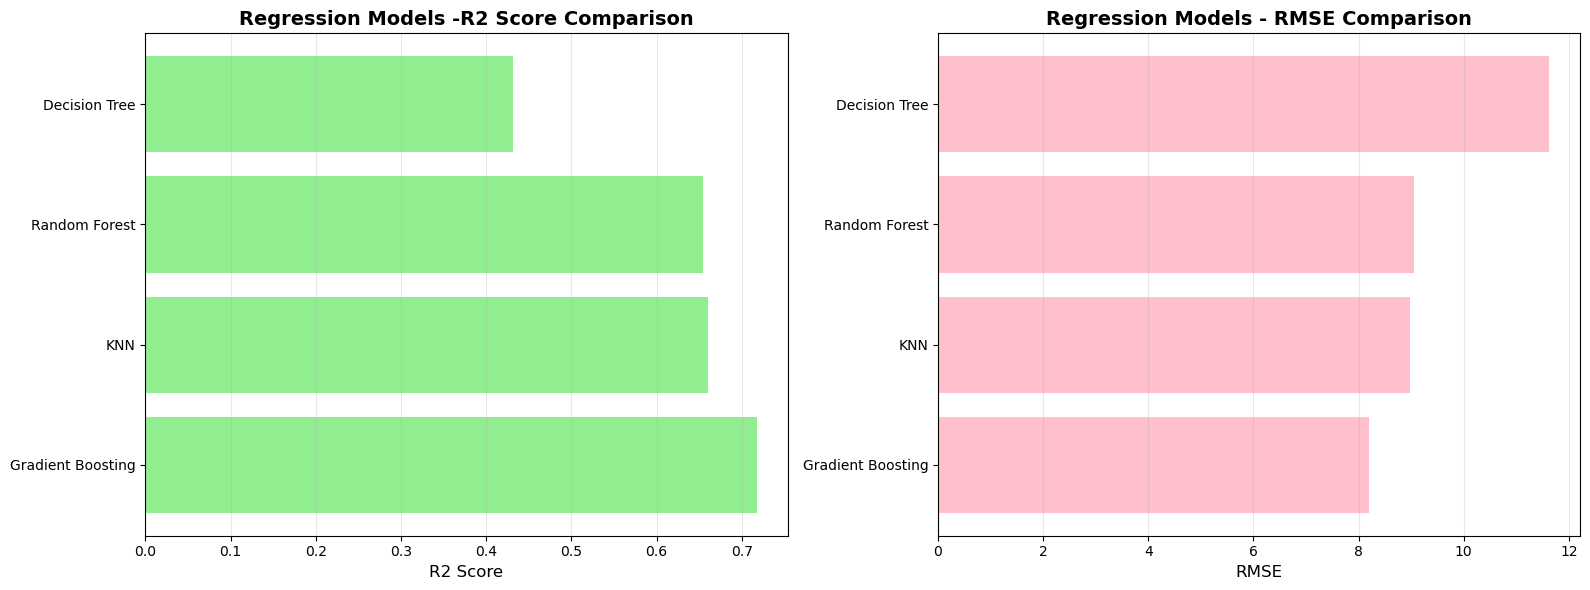


 Best Regression Model: Gradient Boosting

 Best R2 Score: 0.7178 (71.78% accuray)


In [13]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

#R2 score comparison
axes[0].barh(df_reg_results['Model'], df_reg_results['R2 Score'], color='lightgreen')
axes[0].set_xlabel('R2 Score', fontsize=12)
axes[0].set_title('Regression Models -R2 Score Comparison', fontsize=14, fontweight= 'bold')
axes[0].grid(axis='x', alpha=0.3)   

# RMSE comparison
axes[1].barh(df_reg_results['Model'], df_reg_results['RMSE'], color='pink')
axes[1].set_xlabel('RMSE', fontsize=12)
axes[1].set_title('Regression Models - RMSE Comparison', fontsize=14, fontweight= 'bold')
axes[1].grid(axis='x', alpha=0.3)   

plt.tight_layout()
plt.show()

#best model
best_reg_model = df_reg_results.iloc[0]['Model']
best_r2 = df_reg_results.iloc[0]['R2 Score']
print(f"\n Best Regression Model: {best_reg_model}")
print(f"\n Best R2 Score: {best_r2:.4f} ({best_r2*100:.2f}% accuray)")


#### Training Classification Model

In [14]:
classification_models = {}
classification_results = []

# Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_clf_scaled, y_train_clf)
classification_models['Decision Tree'] = dt_clf

# Random Forest Classifier   
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf)
classification_models['Random Forest'] = rf_clf

# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train_clf_scaled, y_train_clf)
classification_models['Gradient Boosting'] = gb_clf

# K nearest Neighbour Classifier 
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_clf_scaled, y_train_clf)
classification_models['KNN'] = knn_clf

#### Evaluate Model

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
for name, model in classification_models.items():
    y_pred = model.predict(X_test_clf_scaled)

    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test_clf, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test_clf, y_pred, average='weighted', zero_division=0)

    classification_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 score': f1
    })  #   Storing results
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

# create dataframe
df_clf_results = pd.DataFrame(classification_results)
df_clf_results = df_clf_results.sort_values('Accuracy', ascending=False)


Decision Tree:
Accuracy: 0.6029 (60.29%)
Precision: 0.6084
Recall: 0.6029
F1 Score: 0.6056

Random Forest:
Accuracy: 0.6443 (64.43%)
Precision: 0.6360
Recall: 0.6443
F1 Score: 0.6398

Gradient Boosting:
Accuracy: 0.6969 (69.69%)
Precision: 0.6823
Recall: 0.6969
F1 Score: 0.6884

KNN:
Accuracy: 0.6508 (65.08%)
Precision: 0.6484
Recall: 0.6508
F1 Score: 0.6493


#### Visualize Classification Model

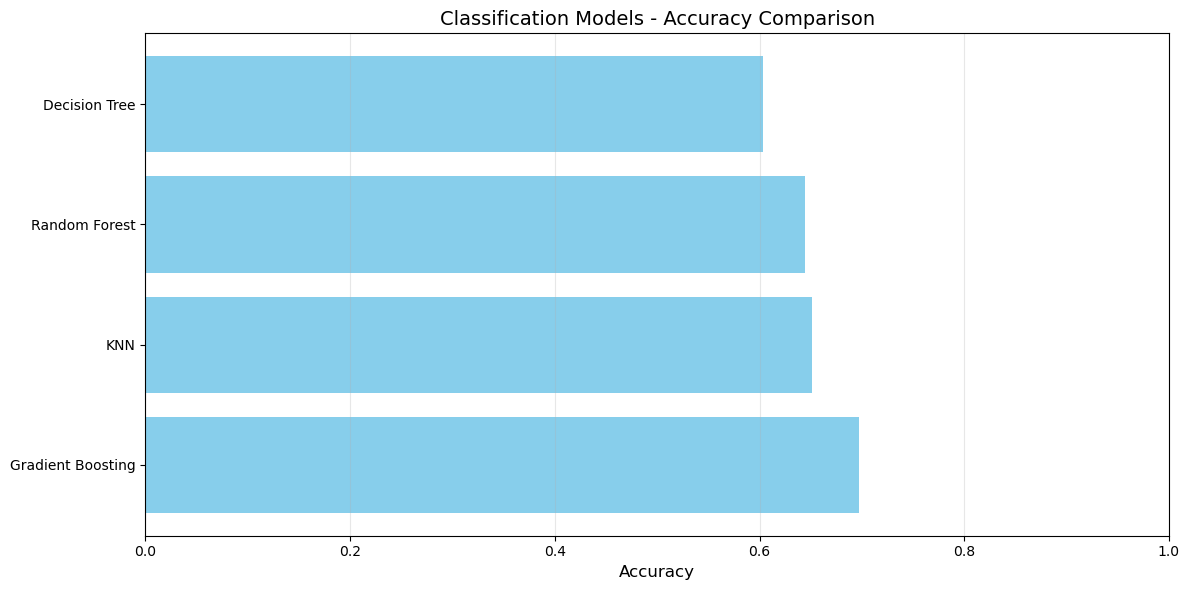


 Best Classification Model: Gradient Boosting
 Accuracy: 0.6969 (69.69%)


In [16]:
plt.figure(figsize=(12, 6))

# Accuracy comparison
plt.barh(df_clf_results['Model'], df_clf_results['Accuracy'], color='skyblue')
plt.xlabel('Accuracy', fontsize=12)
plt.title('Classification Models - Accuracy Comparison', fontsize=14)
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Best model
best_clf_model = df_clf_results.iloc[0]['Model']
best_accuracy = df_clf_results.iloc[0]['Accuracy']

print(f"\n Best Classification Model: {best_clf_model}")
print(f" Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

#### Prediction on New DATA

In [17]:
# New student data
new_students = pd.DataFrame({
    'weekly_self_study_hours': [15.0, 25.0, 10.0, 20.0, 5.0],
    'attendance_percentage': [85.0, 95.0, 70.0, 90.0, 60.0],
    'class_participation': [4.0, 8.0, 3.0, 7.0, 2.0]
})

print(new_students)

new_students_scaled = scaler.transform(new_students) #scaling

best_reg = regression_models[best_reg_model] #best reg model
best_clf = classification_models[best_clf_model]#best clf model

#make prediction
predicted_scores = best_reg.predict(new_students_scaled)
predicted_grades_handled = best_clf.predict(new_students_scaled)

#convert handled grade back to letters
grade_reverse_mapping = {4: 'A', 3: 'B', 2: 'C', 1: 'D', 0: 'F'}
predicted_grades = [grade_reverse_mapping[g] for g in predicted_grades_handled]

# Add predictions to DataFrame
new_students['predicted_score'] = predicted_scores
new_students['predicted_grade'] = predicted_grades

print("PREDICTIONS:")
print(new_students)

   weekly_self_study_hours  attendance_percentage  class_participation
0                     15.0                   85.0                  4.0
1                     25.0                   95.0                  8.0
2                     10.0                   70.0                  3.0
3                     20.0                   90.0                  7.0
4                      5.0                   60.0                  2.0
PREDICTIONS:
   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     15.0                   85.0                  4.0   
1                     25.0                   95.0                  8.0   
2                     10.0                   70.0                  3.0   
3                     20.0                   90.0                  7.0   
4                      5.0                   60.0                  2.0   

   predicted_score predicted_grade  
0        87.123680               A  
1        99.386483               A  
2    

#### Interactive Prediction

In [18]:
print("\n Enter your details:")

study_hours = float(input("Weekly self study hours(0-40): "))
attendance = float(input("Attendance Percentage(0-100): "))
participation = float(input("Class participation(0-10): "))

#DATAFRAME
student_data = pd.DataFrame({
    'weekly_self_study_hours': [study_hours],
    'attendance_percentage': [attendance],
    'class_participation': [participation]
})

# Scale
student_scaled = scaler.transform(student_data)

# predict
predicted_score = best_reg.predict(student_scaled)[0]
predicted_grade_code = best_clf.predict(student_scaled)[0]
predicted_grade = grade_reverse_mapping[predicted_grade_code]


# Display prediction 
print("\n YOUR PREDICTED PERFORMANCE")
print(f"\n Study Hours: {study_hours} hours/week")
print(f"Attendance: {attendance}%")
print(f"Participation: {participation}/10")
print(f"Predicted Score: {predicted_score:.2f}/100")
print(f"Predicted Grade: {predicted_grade}")


# Performance message
if predicted_grade in ['A', 'B']:
    print(" Excellent performance! Keep it up!")
elif predicted_grade == 'C':
    print(" Good, you can do better!")
else:
    print(" Need more effort, Study harder! ")


 Enter your details:

 YOUR PREDICTED PERFORMANCE

 Study Hours: 10.0 hours/week
Attendance: 70.0%
Participation: 5.0/10
Predicted Score: 75.20/100
Predicted Grade: B
 Excellent performance! Keep it up!


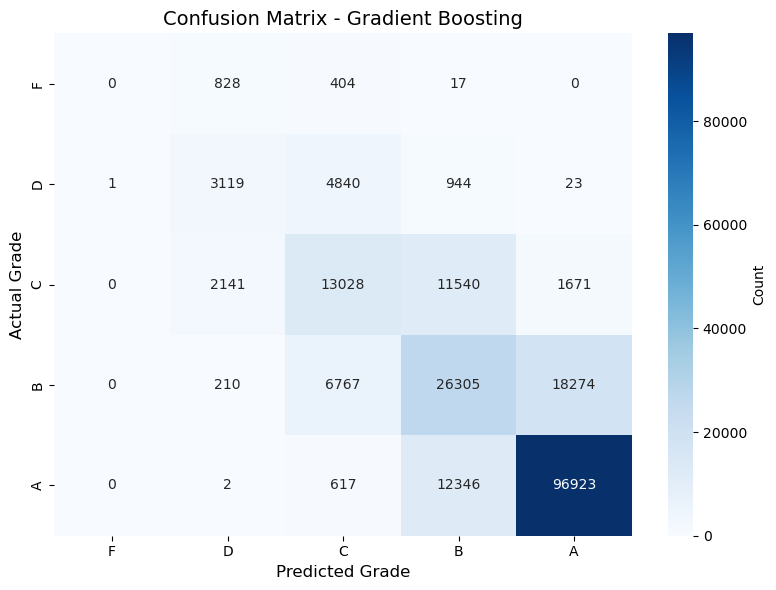

In [19]:
y_pred_clf = best_clf.predict(X_test_clf_scaled) # get prediction

cm = confusion_matrix(y_test_clf, y_pred_clf) # creates confusion matrix

#plot

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['F', 'D', 'C', 'B', 'A'],
            yticklabels=['F', 'D', 'C', 'B', 'A'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_clf_model}', fontsize=14)
plt.xlabel('Predicted Grade', fontsize=12)
plt.ylabel('Actual Grade', fontsize=12)
plt.tight_layout()
plt.show()



#### Feature Importance Analysis 
##### Shows which features (input variables) matter most for making predictions.



 Regression (Predicting Score)
 weekly_self_study_hours        0.7633 (76.3%) ||||||||||||||||||||||||||||||||||||||
 Regression (Predicting Score)
 attendance_percentage          0.1370 (13.7%) ||||||
 Regression (Predicting Score)
 class_participation            0.0997 (10.0%) ||||
 Classification (Predicting Score)
 weekly_self_study_hours        0.4932 (49.3%) ||||||||||||||||||||||||
 Classification (Predicting Score)
 attendance_percentage          0.3527 (35.3%) |||||||||||||||||
 Classification (Predicting Score)
 class_participation            0.1541 (15.4%) |||||||


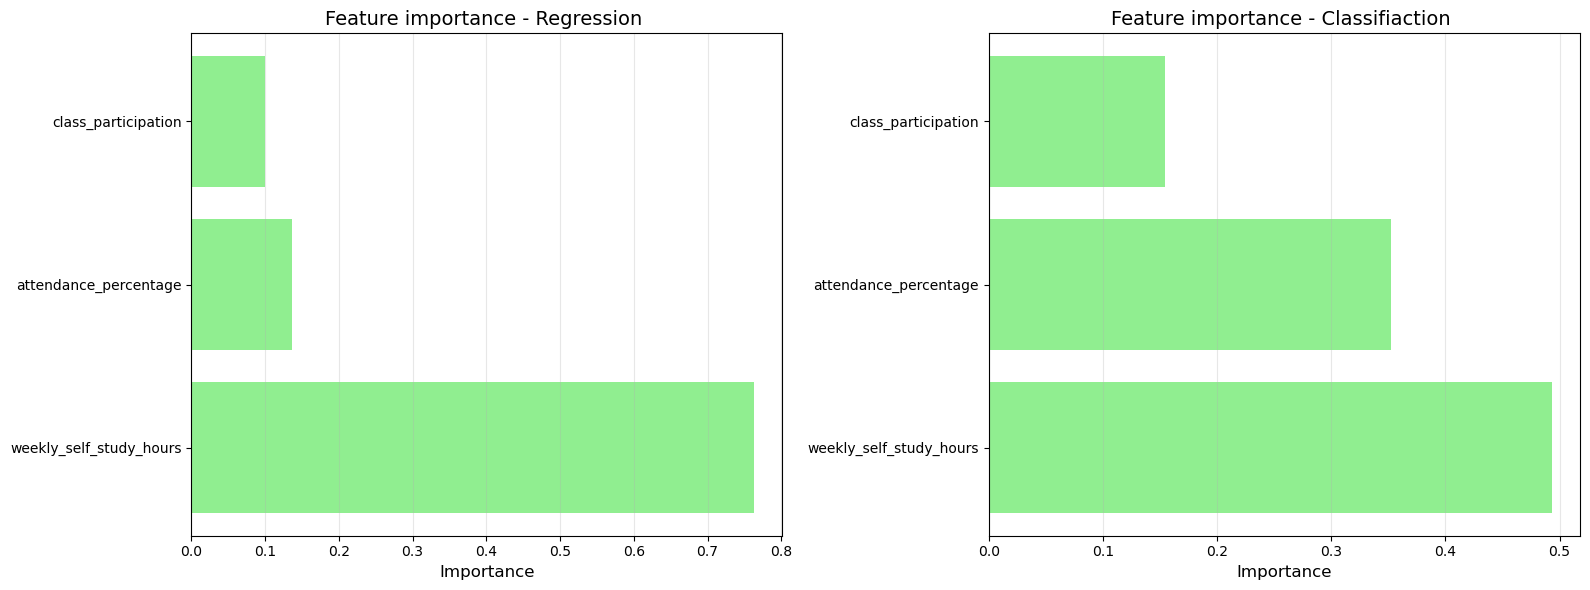

In [22]:
feature_names = X.columns

#regression feature importance
if 'Random Forest' in regression_models:
    rf_reg_importance = regression_models['Random Forest'].feature_importances_

    for feature, importance in zip(feature_names, rf_reg_importance):
        print(" Regression (Predicting Score)")
        percentage = importance * 100
        bar = '|' * int(percentage/2)   
        print(f" {feature:30} {importance:.4f} ({percentage:.1f}%) {bar}")

#classification feature importance
if 'Random Forest' in classification_models:
    rf_clf_importance = classification_models['Random Forest'].feature_importances_

    for feature, importance in zip(feature_names, rf_clf_importance):
        print(" Classification (Predicting Score)")
        percentage = importance * 100
        bar = '|' * int(percentage/2)   
        print(f" {feature:30} {importance:.4f} ({percentage:.1f}%) {bar}")

#vizualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names, rf_reg_importance, color='lightgreen')
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Feature importance - Regression ', fontsize=14)
axes[0].grid(axis='x', alpha=0.3)


axes[1].barh(feature_names, rf_clf_importance, color='lightgreen')
axes[1].set_xlabel('Importance', fontsize=12)
axes[1].set_title('Feature importance - Classifiaction ', fontsize=14)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


#### Save Model

In [26]:
import pickle

#save best reg model
with open(f'{best_reg_model.lower().replace(" ", "_")}_regressor.pkl','wb') as f:
    pickle.dump(best_reg, f)
print(f"{best_reg_model} regressor Saved")

#save best clf model
with open(f'{best_clf_model.lower().replace(" ", "_")}_classifier.pkl','wb') as f:
    pickle.dump(best_clf, f)
print(f"{best_reg_model} Classifier Saved")

#save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f" StandardScaler Saved")

#save result
df_reg_results.to_csv('regresssion_result.csv', index=False)
df_clf_results.to_csv('classification_results.csv', index=False)

Gradient Boosting regressor Saved
Gradient Boosting Classifier Saved
 StandardScaler Saved


#### Load Model

In [27]:
import pickle
import pandas as pd
import numpy as np

# Load best regression model
with open(f'{best_reg_model.lower().replace(" ", "_")}_regressor.pkl', 'rb') as f:
    loaded_reg_model = pickle.load(f)
print(f"{best_reg_model} Regressor Loaded")

# Load best classification model
with open(f'{best_clf_model.lower().replace(" ", "_")}_classifier.pkl', 'rb') as f:
    loaded_clf_model = pickle.load(f)
print(f"{best_clf_model} Classifier Loaded")

# Load scaler
with open('scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)
print(f"StandardScaler Loaded")


Gradient Boosting Regressor Loaded
Gradient Boosting Classifier Loaded
StandardScaler Loaded


#### Make Prediction

In [31]:
print("\n Enter your details:")

study_hours = float(input("Weekly self study hours(0-40): "))
attendance = float(input("Attendance Percentage(0-100): "))
participation = float(input("Class participation(0-10): "))

#DATAFRAME
student_data = pd.DataFrame({
    'weekly_self_study_hours': [study_hours],
    'attendance_percentage': [attendance],
    'class_participation': [participation]
})

# Scale
student_scaled = scaler.transform(student_data)

# predict
predicted_score = best_reg.predict(student_scaled)[0]
predicted_grade_code = best_clf.predict(student_scaled)[0]
predicted_grade = grade_reverse_mapping[predicted_grade_code]


# Display prediction 
print("\n YOUR PREDICTED PERFORMANCE")
print(f"\n Study Hours: {study_hours} hours/week")
print(f"Attendance: {attendance}%")
print(f"Participation: {participation}/10")
print(f"Predicted Score: {predicted_score:.2f}/100")
print(f"Predicted Grade: {predicted_grade}")


# Performance message
if predicted_grade in ['A', 'B']:
    print(" Excellent performance! Keep it up!")
elif predicted_grade == 'C':
    print(" Good, you can do better!")
else:
    print(" Need more effort, Study harder! ")


 Enter your details:

 YOUR PREDICTED PERFORMANCE

 Study Hours: 10.0 hours/week
Attendance: 100.0%
Participation: 10.0/10
Predicted Score: 75.21/100
Predicted Grade: B
 Excellent performance! Keep it up!
